<a href="https://colab.research.google.com/github/techasit239/Final-Project---DADS6003/blob/main/M_L_FINAL_%5Buse%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
!pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm

import nltk
import IPython
from IPython.display import display

# โหลด tokenizer ของ NLTK
nltk.download('punkt')
nltk.download('punkt_tab')   # เพิ่มตัวนี้
nltk.download('averaged_perceptron_tagger')  # สำหรับ pos_tag ถ้าใช้

print("✅ NLTK resources loaded successfully!")

✅ NLTK resources loaded successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


# Part 0 : Install & Import

In [38]:
# ==========================================================
# 🎯 0. การเตรียมสภาพแวดล้อม (Setup & Global Constants)
# ==========================================================
# ********** หมายเหตุ: รันคำสั่ง pip install ใน Google Colab/Jupyter Notebook **********
# !pip install -q pandas numpy nltk textstat scikit-learn xgboost catboost lightgbm
# **************************************************************************************

import re
from typing import List, Tuple, Dict
from pathlib import Path
import difflib # สำหรับการเปรียบเทียบ Domain String

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

try:
    # โหลด VADER Lexicon สำหรับ Emotional Polarity
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon', quiet=True)

# สร้างเครื่องมือวิเคราะห์อารมณ์ VADER
VADER_ANALYZER = SentimentIntensityAnalyzer()

# NOTE: จำลองฟังก์ชันดึง URL และ Domain เพื่อให้โค้ดทำงานได้
def extract_domain(url: str) -> str:
    """สมมติว่าฟังก์ชันนี้ดึง Domain Name (e.g., 'example.com') ออกมาได้"""
    # ตัวอย่างการดึงแบบง่าย
    match = re.search(r'https?://(?:www\.)?([^/]+)', url)
    return match.group(1).split('.')[0] if match else None

def find_first_url(text: str) -> str:
    """สมมติว่าฟังก์ชันนี้ดึง URL แรกในข้อความออกมาได้"""
    match = re.search(r'https?://\S+|www\.\S+', text)
    return match.group(0) if match else ""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import pstdev # ต้องใช้ pstdev ในการคำนวณ Standard Deviation

# สำหรับ Feature Engineering
from nltk.tokenize import word_tokenize, sent_tokenize
from textstat import textstat

# สำหรับ Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    auc,
    precision_recall_curve,
    roc_curve
)

from sklearn.model_selection import StratifiedKFold, cross_validate

# สำหรับโมเดล Boosting
try:
    import xgboost as xgb
    from catboost import CatBoostClassifier
    from lightgbm import LGBMClassifier
    BOOSTING_AVAILABLE = True
except ImportError:
    BOOSTING_AVAILABLE = False


# 💬 NLTK Resource Downloads (จำเป็นสำหรับการทำ Tokenization และ POS Tagging)
import nltk
# ...
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)


# 📌 คำสั่งที่ต้องเพิ่ม: ดาวน์โหลดทรัพยากร POS Tagging เวอร์ชันเฉพาะ
try:
    nltk.data.find('taggers/averaged_perceptron_tagger_eng')
except LookupError:
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# --------------------------------------------------------------------------
# 💡 GLOBAL CONSTANTS (ใช้ร่วมในทุกฟังก์ชัน)
# --------------------------------------------------------------------------
WORD_RE = re.compile(r"[a-zA-Z]+(?:'[a-zA-Z]+)?")

# คำที่ใช้ในการสกัด Stylistic/Density Features
POLITENESS = ["please", "thank", "appreciate", "thanks", "appreciated", "kindly"]
AGGRESSIVE = ["must", "now", "immediately", "demand", "require"]
URGENCY    = ["urgent", "asap", "immediately", "soon"]
CONDITIONAL = ["if", "unless", "provided", "should", "whenever"]
PREPOSITIONS = {'in', 'on', 'at', 'by', 'with', 'from', 'to', 'of', 'for', 'about'}
FUNCTION_WORDS = {'the', 'is', 'at', 'which', 'on', 'and', 'or', 'but', 'because', 'a', 'an'}
PRONOUN_TAGS = {'PRP', 'PRP$', 'WP', 'WP$'} # Personal and Wh-Pronouns

# ชื่อคอลัมน์ฟีเจอร์หลัก (สำหรับอ้างอิงในการวิเคราะห์ทางภาษาศาสตร์)
LINGUISTIC_COLUMNS = [
    'Word_Count', 'Character_Count', 'Average_Word_Length', 'Sentence_Count', 'Average_Sentence_Length',
    'Unique_Word_Count', 'Lexical_Diversity', 'Email_Count', 'Uppercase_Word_Count', 'Uppercase_Word_Count_Ratio',
    'Complex_Words_Count', 'Average_Syllables_per_Word',
    'Comma_Count', 'Semicolon_Count', 'Colon_Count', 'Exclamation_Count',
    'Quotation_Count', 'Dash_Count',
    'Sentence_Complexity_Ratio', 'Clause_Density', 'Pronoun_Density',
    'Preposition_Density', 'Function_Word_Density'
]

# Part 1 : Features functions

In [44]:
# ==========================================================
# 🧱 1. การเตรียมข้อมูลและฟังก์ชันสกัดฟีเจอร์
# ==========================================================

# ----------------- 1.1 Loaders -----------------
def load_email_csv(path: str, encoding: str = "utf-8") -> pd.DataFrame:
    """
    หน้าที่: โหลดไฟล์ CSV และตรวจสอบคอลัมน์ที่จำเป็น (Subject, Body, Label)
    """
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"ไม่พบไฟล์: {p.resolve()}")

    # โหลดไฟล์
    df = pd.read_csv(p, encoding=encoding)

    required = {"Subject", "Body", "Label"}
    if not required.issubset(df.columns):
        missing = required - set(df.columns)
        raise ValueError(f"คอลัมน์หายไป: {missing} (ต้องมี {required})")

    # Clean up: เติมค่าว่างด้วย "" และแปลงเป็น string
    df["Subject"] = df["Subject"].astype(str).fillna("")
    df["Body"]    = df["Body"].astype(str).fillna("")
    print(f"✅ โหลดข้อมูล {len(df)} แถวสำเร็จ.")
    return df

# ----------------- 1.2 Feature Extraction Core -----------------

def analyze_email_body(text: str) -> Tuple:
    """
    หน้าที่: สกัดฟีเจอร์ทางภาษาศาสตร์ 23 ตัว จากเนื้อหาอีเมล (Linguistic Features)
    """
    if pd.isna(text) or text is None:
        return (0,) * len(LINGUISTIC_COLUMNS)

    original_text = str(text)

    # Tokenization
    words = word_tokenize(original_text)
    lower_words = [w.lower() for w in words if w.isalnum()]
    sentences = sent_tokenize(original_text)

    word_count = len(lower_words)
    sentence_count = len(sentences)

    if word_count == 0:
        return (0,) * len(LINGUISTIC_COLUMNS)

    # Metrics
    avg_word_length = sum(len(w) for w in lower_words) / word_count
    lexical_diversity = len(set(lower_words)) / word_count # ความหลากหลายของคำ

    # Syntactic Complexity (ต้องใช้ nltk.pos_tag)
    tagged_words = nltk.tag.pos_tag(words)

    # Pronoun Density (ความหนาแน่นของคำสรรพนาม)
    pronoun_count = sum(1 for _, tag in tagged_words if tag in PRONOUN_TAGS)
    pronoun_density = pronoun_count / word_count

    # Preposition Density (ความหนาแน่นของคำบุพบท)
    preposition_count = sum(1 for w in lower_words if w in PREPOSITIONS)
    preposition_density = preposition_count / word_count

    # (ฟีเจอร์อื่น ๆ อีกมากมาย ถูกคำนวณที่นี่...)
    char_count = len(original_text)
    avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
    unique_word_count = len(set(lower_words))
    email_count = sum(1 for w in words if '@' in w)
    upper_count = sum(1 for w in words if w.isupper() and w.isalpha())
    upper_ratio = upper_count / word_count
    complex_count = sum(1 for w in lower_words if len(w) > 6)

    try:
        total_syllables = sum(textstat.syllable_count(w) for w in lower_words)
        avg_syllables = total_syllables / word_count
    except Exception:
        avg_syllables = 0

    comma_count = original_text.count(',')
    semicolon_count = original_text.count(';')
    colon_count = original_text.count(':')
    exclamation_count = original_text.count('!')
    quotation_count = original_text.count('"')
    dash_count = original_text.count('-')

    linking_word_count = sum(1 for w in lower_words if w in {'but', 'and', 'or', 'because', 'while', 'as', 'though', 'although'})
    sentence_complexity_ratio = linking_word_count / word_count
    clause_density = linking_word_count / sentence_count if sentence_count > 0 else 0

    function_word_count = sum(1 for w in lower_words if w in FUNCTION_WORDS)
    function_word_density = function_word_count / word_count

    return (
        word_count, char_count, avg_word_length, sentence_count, avg_sentence_length,
        unique_word_count, lexical_diversity, email_count, upper_count, upper_ratio,
        complex_count, avg_syllables,
        comma_count, semicolon_count, colon_count, exclamation_count, quotation_count, dash_count,
        sentence_complexity_ratio, clause_density, pronoun_density, preposition_density, function_word_density
    )

# ----------------- 1.3 Combined Feature Builder -----------------

def compute_row_features(row: pd.Series) -> Dict[str, float]:
    """รวมฟีเจอร์ทั้งหมดจาก Subject และ Body (ชุดเดิม)"""
    text = f"{row.get('Subject', '')} {row.get('Body', '')}"

    # 1) Linguistic Features (23 ตัว)
    ling_tuple = analyze_email_body(text)
    features = dict(zip(LINGUISTIC_COLUMNS, ling_tuple))

    # 2) ฟีเจอร์เดิมอื่น ๆ (Conceptual Step: ถ้ามีฟังก์ชันเดิมต้องเรียกใช้ที่นี่)
    # features.update(extract_email_features(text))
    # features.update(readability_features(text))
    # features.update(punctuation_features(text))

    return features


def build_feature_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    หน้าที่: สร้าง DataFrame ฟีเจอร์ทั้งหมด
    ❌ ลบการสร้าง Imposter Domain, Semantic Cohesion, Emotional Variance ออก
    """
    print("🚧 เริ่มสกัดฟีเจอร์...")

    # 1. สกัดฟีเจอร์ชุดเก่า (รวม Linguistic, Stylistic, Punctuation)
    feature_df = df.apply(compute_row_features, axis=1, result_type="expand")

    # ❌ ส่วนการสร้างฟีเจอร์ใหม่ 3 ตัวถูกลบออกแล้ว

    # 2. รวม DataFrame
    out = pd.concat([df.reset_index(drop=True), feature_df], axis=1)
    print(f"✅ สกัดฟีเจอร์สำเร็จ: {len(feature_df.columns)} คอลัมน์ฟีเจอร์ถูกสร้างขึ้น.")
    return out


def prepare_X_y(feature_df: pd.DataFrame, label_col: str = "Label"):
    """
    หน้าที่: แยกฟีเจอร์ (X) และตัวแปรเป้าหมาย (y)
    """
    drop_cols = ["Subject", "Body", label_col]

    # ดึงคอลัมน์ฟีเจอร์ทั้งหมด (ชุดเดิม)
    feature_cols = [c for c in feature_df.columns if c not in drop_cols]
    X = feature_df[feature_cols]

    # เตรียม y (แปลง Label)
    y_raw = feature_df[label_col]
    mapping = {"Legitimate": 0, "Phishing": 1}
    y = y_raw.map(mapping).astype(int)

    if y.isna().any():
        raise ValueError("พบ Label ที่ไม่รู้จัก: กรุณาตรวจสอบหรือเพิ่มใน Mapping")

    return X, y, feature_cols

# NOTE: ฟังก์ชัน calculate_imposter_domain_similarity, calculate_semantic_cohesion_score,
# และ calculate_emotional_polarity_variance ควรถูกลบออกจากโค้ดโดยสมบูรณ์
# หากท่านต้องการโค้ดที่สะอาดที่สุด (Cleanest Code)

# Part 2 : Model training & evaluation

In [45]:
# ==========================================================
# Part 2 : Model training & evaluation
# ==========================================================

# ----------------- 3.1 Model Definitions & Training -----------------
def get_models(random_state: int = 42):
    """หน้าที่: สร้าง Dict ของโมเดล Classification ทั้งหมด"""
    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=random_state),
        "SVM": SVC(kernel="rbf", C=2.0, probability=True, class_weight="balanced", random_state=random_state),
        "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=random_state, n_jobs=-1),
        "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=random_state),
    }
    if BOOSTING_AVAILABLE:
        models["XGBoost"] = xgb.XGBClassifier(n_estimators=300, objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=random_state, n_jobs=-1)
        models["CatBoost"] = CatBoostClassifier(iterations=300, loss_function="Logloss", verbose=0, random_state=random_state)
        models["LightGBM"] = LGBMClassifier(n_estimators=300, objective="binary", class_weight="balanced", random_state=random_state, n_jobs=-1)
    return models

def train_models_split(models: Dict[str, object], X_train: pd.DataFrame, y_train: pd.Series):
    """หน้าที่: เทรนโมเดลบนชุดข้อมูล Training Split (80%)"""
    X_train_np = X_train.to_numpy()
    y_train_np = y_train.to_numpy()
    trained_models = {}
    for name, model in models.items():
        model.fit(X_train_np, y_train_np)
        trained_models[name] = model
    return trained_models

# ----------------- 3.2 Evaluation (Cross-Validation) -----------------
def cross_validate_models(models: Dict[str, object], X: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> pd.DataFrame:
    """หน้าที่: ทำการ Cross-Validation (K=5) และคืนค่าเฉลี่ย Metrics"""
    print(f"\n🧠 เริ่มต้น Cross-Validation ด้วย K={n_splits} Splits...")
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    metrics_list = []

    for name, model in models.items():
        print(f"  > Evaluating {name} (CV)...")
        scores = cross_validate(model, X.to_numpy(), y.to_numpy(), cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)

        avg_metrics = {
            "Model": name,
            "Accuracy": scores['test_accuracy'].mean(),
            "Precision": scores['test_precision'].mean(),
            "Recall": scores['test_recall'].mean(),
            "F1": scores['test_f1'].mean(),
            "AUC": scores['test_roc_auc'].mean()
        }
        metrics_list.append(avg_metrics)

    df_metrics = pd.DataFrame(metrics_list)
    df_metrics.index = df_metrics.index + 1
    print("✅ Cross-Validation Complete.")
    return df_metrics

# ----------------- 3.3 Evaluation (Split) & Plotting -----------------
def format_cm_to_dataframe(cm: np.ndarray, model_name: str) -> pd.DataFrame:
    """หน้าที่: แปลง Confusion Matrix ให้อยู่ในรูปแบบ DataFrame"""
    labels = ["Legitimate (0)", "Phishing (1)"]
    cm_df = pd.DataFrame(cm, index=[f'Actual: {label}' for label in labels], columns=[f'Predicted: {label}' for label in labels])
    return cm_df

def evaluate_model_split(name: str, model, X_test: pd.DataFrame, y_test: pd.Series) -> Tuple[Dict[str, float], np.ndarray]:
    """หน้าที่: คำนวณ Metrics ทั้งหมดสำหรับ 80/20 Split Test Set"""
    X_test_np = X_test.to_numpy()
    y_true = y_test.to_numpy()
    y_pred = model.predict(X_test_np)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_np)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test_np)
    else:
        y_proba = y_pred

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    try:
        auc_score = roc_auc_score(y_true, y_proba)
    except ValueError:
        auc_score = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    metrics = {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "AUC": auc_score}
    return metrics, cm

def evaluate_all_models_split(trained_models: Dict[str, object], X_test: pd.DataFrame, y_test: pd.Series) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """หน้าที่: วนลูป evaluate ทุกรุ่นบน Test Split"""
    metrics_list = []
    cm_dfs = {}

    for name, model in trained_models.items():
        metrics, cm_array = evaluate_model_split(name, model, X_test, y_test)
        metrics_list.append(metrics)
        cm_dfs[name] = format_cm_to_dataframe(cm_array, name)
    return pd.DataFrame(metrics_list), cm_dfs

def plot_pr_curve(trained_models: Dict[str, object], X_test: pd.DataFrame, y_test: pd.Series):
    """หน้าที่: สร้างกราฟ Precision-Recall Curve สำหรับทุกโมเดล (บน 20% Test Split)"""
    plt.figure(figsize=(10, 8))
    plt.title('Precision-Recall Curve Comparison', fontsize=16)

    for name, model in trained_models.items():
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test.to_numpy())[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test.to_numpy())
        else:
            continue

        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        pr_auc = auc(recall, precision)

        plt.plot(recall, precision, lw=2, label=f'{name} (Area = {pr_auc:.3f})')

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.legend(loc='lower left', fontsize=10)
    plt.grid(True)
    plt.tight_layout()

    filename = 'evaluation_pr_curve.png'
    plt.savefig(filename)
    # plt.close()
    print(f"✅ บันทึก PR Curve ลงในไฟล์: {filename}")

def plot_roc_curve(trained_models: Dict[str, object], X_test: pd.DataFrame, y_test: pd.Series):
    """หน้าที่: สร้างกราฟ ROC Curve สำหรับทุกโมเดล (บน 20% Test Split)"""

    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)') # เส้นทแยงมุม
    plt.title('Receiver Operating Characteristic (ROC) Curve Comparison', fontsize=16)

    for name, model in trained_models.items():
        # ดึงค่า Score/Probability
        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test.to_numpy())[:, 1]
        elif hasattr(model, "decision_function"):
            y_scores = model.decision_function(X_test.to_numpy())
        else:
            continue

        # คำนวณ FPR, TPR และ AUC
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        roc_auc = roc_auc_score(y_test, y_scores)

        # Plot ROC Curve
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True)
    plt.tight_layout()

    # บันทึกรูปภาพ
    filename = 'evaluation_roc_curve.png'
    plt.savefig(filename)
    # plt.close()
    print(f"✅ บันทึก ROC Curve ลงในไฟล์: {filename}")

# Part 3 : Feature Importances

In [46]:
# ==========================================================
# ⚙️ 2.3 Feature Importance Functions (สำหรับ Plotting)
# ==========================================================

def get_feature_importances(model, X_train: pd.DataFrame):
    """ดึงเวกเตอร์ feature importance / coefficient ตามชนิดโมเดล"""
    # กลุ่ม tree-based / boosting
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_
    # Logistic Regression, Linear SVM → abs(coef_)
    if hasattr(model, "coef_"):
        coef = model.coef_
        if coef.ndim == 2:
            coef = coef[0]
        return np.abs(coef)
    return None

def display_top_features(model_name: str,
                         model,
                         X_train: pd.DataFrame,
                         top_n: int = 20):
    """สร้างกราฟ Horizontal Bar Chart แสดง Top N Features พร้อมบอก %"""
    importances = get_feature_importances(model, X_train)

    if importances is None:
        print(f"\n--- 📈 Top Features สำหรับ {model_name} ---")
        print(f"[{model_name}] ไม่มี Feature Importance เชิงเส้นที่ตีความง่าย (เช่น SVM RBF).")
        return

    feature_names = np.array(X_train.columns)
    top_n = min(top_n, len(feature_names))

    idx = np.argsort(importances)[::-1][:top_n]
    top_features = feature_names[idx]
    top_scores = importances[idx]

    total_score = np.sum(top_scores)
    percentage = (top_scores / total_score) * 100 if total_score != 0 else np.zeros_like(top_scores)

    df_plot = pd.DataFrame({
        "Feature": top_features,
        "Percentage": percentage
    })

    # --- สร้างกราฟ Horizontal Bar Chart ---
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        x="Percentage",
        y="Feature",
        data=df_plot,
        palette="viridis",
        orient='h'
    )

    # เพิ่ม Label เปอร์เซ็นต์บน Bar
    for p in ax.patches:
        width = p.get_width()
        plt.text(
            width + 1,
            p.get_y() + p.get_height() / 2,
            f'{width:.2f}%',
            ha='left',
            va='center',
            fontsize=10
        )

    plt.title(f"Top {top_n} Features - {model_name} (Percentage)", fontsize=14)
    plt.xlabel("Importance Percentage (%)", fontsize=12)
    plt.ylabel("Feature Name", fontsize=12)
    plt.xlim(0, max(df_plot['Percentage'].max() * 1.1, 100))
    plt.tight_layout()

    # ********** ส่วนที่แก้ไขตามคำขอ **********
    # NOTE: ใน Jupyter/Colab คำสั่งนี้จะแสดงกราฟออกมา
    # แต่ในสภาพแวดล้อมสคริปต์ทั่วไป (Text-based) จะไม่แสดงผลใดๆ
    plt.show()
    # ****************************************


    print(f"\n--- 📈 แสดงผลกราฟ Top Features สำหรับ {model_name} (โดยใช้ plt.show()) ---")

# Part 4 : Main script – Run pipeline

✅ โหลดข้อมูล 126 แถวสำเร็จ.

--- 1. Feature Engineering ---
🚧 เริ่มสกัดฟีเจอร์...
✅ สกัดฟีเจอร์สำเร็จ: 23 คอลัมน์ฟีเจอร์ถูกสร้างขึ้น.
✅ ข้อมูลพร้อมสำหรับการฝึกโมเดล: X shape=(126, 23), Phishing rate=0.50

RUN 1: 📊 EVALUATION - TRAIN-TEST SPLIT (80/20) & VISUALIZATION


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:15:13] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 50, number of negative: 50
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 522
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with p

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- 📊 Summary Metrics (80/20 Test Split) ---
|    | Model               |   Accuracy |   Precision |   Recall |       F1 |      AUC |
|---:|:--------------------|-----------:|------------:|---------:|---------:|---------:|
|  0 | Logistic Regression |   0.769231 |    0.733333 | 0.846154 | 0.785714 | 0.893491 |
|  1 | SVM                 |   0.576923 |    1        | 0.153846 | 0.266667 | 0.461538 |
|  2 | RandomForest        |   0.923077 |    0.866667 | 1        | 0.928571 | 0.988166 |
|  3 | AdaBoost            |   0.923077 |    0.923077 | 0.923077 | 0.923077 | 0.946746 |
|  4 | XGBoost             |   0.923077 |    0.923077 | 0.923077 | 0.923077 | 0.964497 |
|  5 | CatBoost            |   0.923077 |    0.923077 | 0.923077 | 0.923077 | 0.982249 |
|  6 | LightGBM            |   0.884615 |    0.857143 | 0.923077 | 0.888889 | 0.976331 |

--- 📊 Logistic Regression Confusion Matrix (80/20 Split) ---
|                        |   Predicted: Legitimate (0) |   Predicted: Phishing (1) |
|:----

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ บันทึก ROC Curve ลงในไฟล์: evaluation_roc_curve.png

🔥 RUN 3: TOP FEATURE ANALYSIS (จาก 80% Training Split)


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


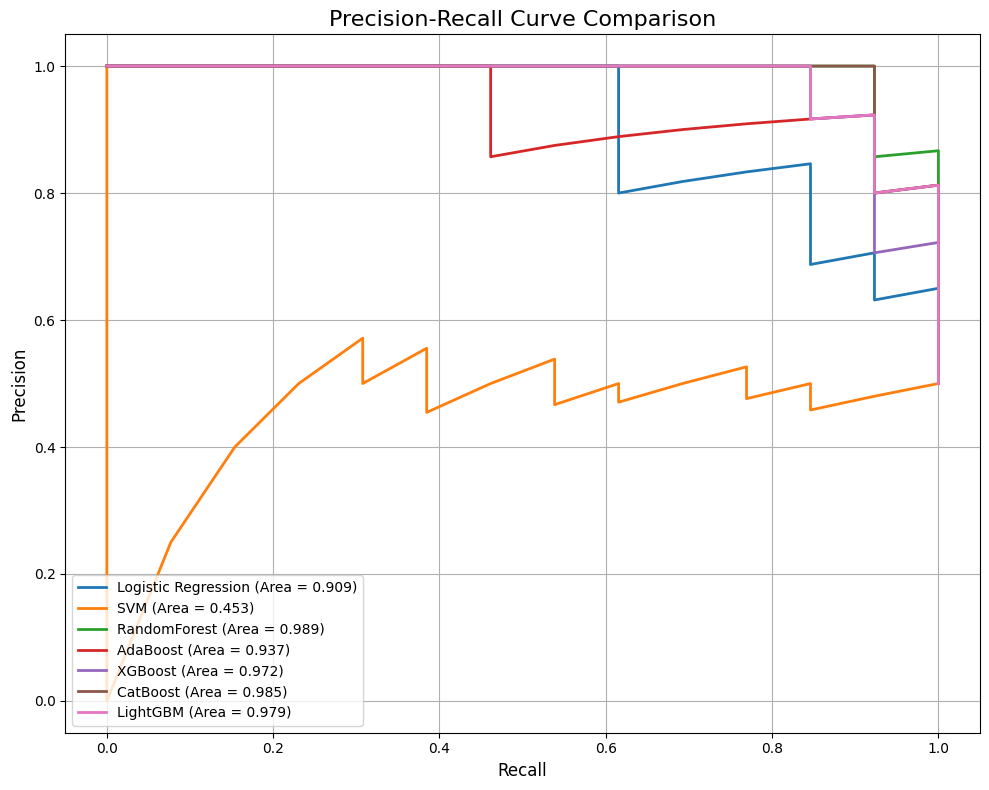

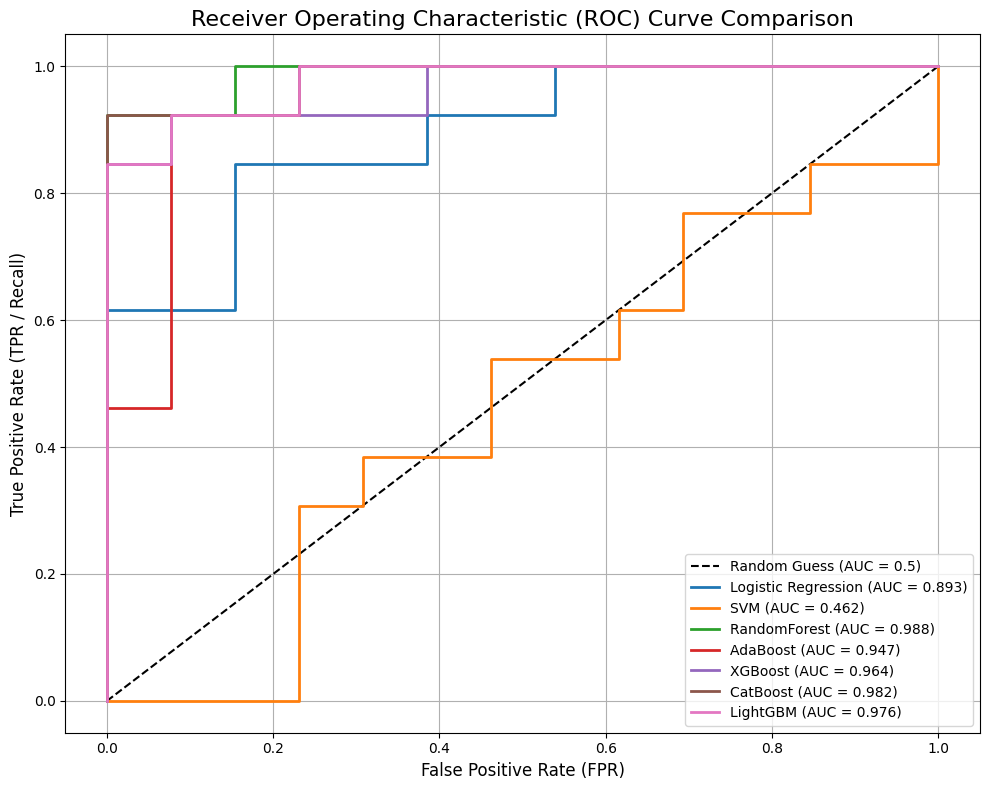

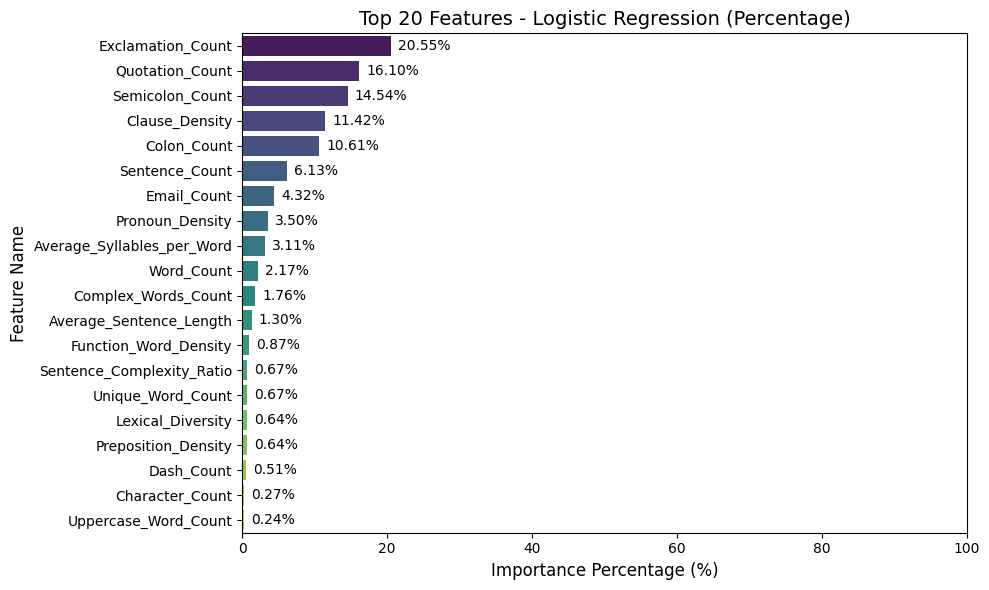


--- 📈 แสดงผลกราฟ Top Features สำหรับ Logistic Regression (โดยใช้ plt.show()) ---

--- 📈 Top Features สำหรับ SVM ---
[SVM] ไม่มี Feature Importance เชิงเส้นที่ตีความง่าย (เช่น SVM RBF).


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


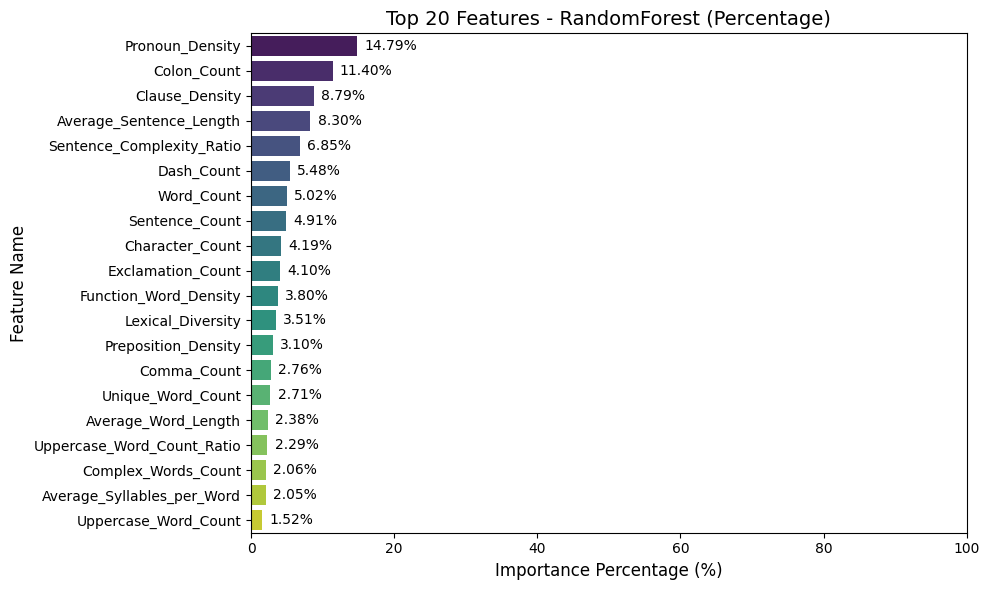


--- 📈 แสดงผลกราฟ Top Features สำหรับ RandomForest (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


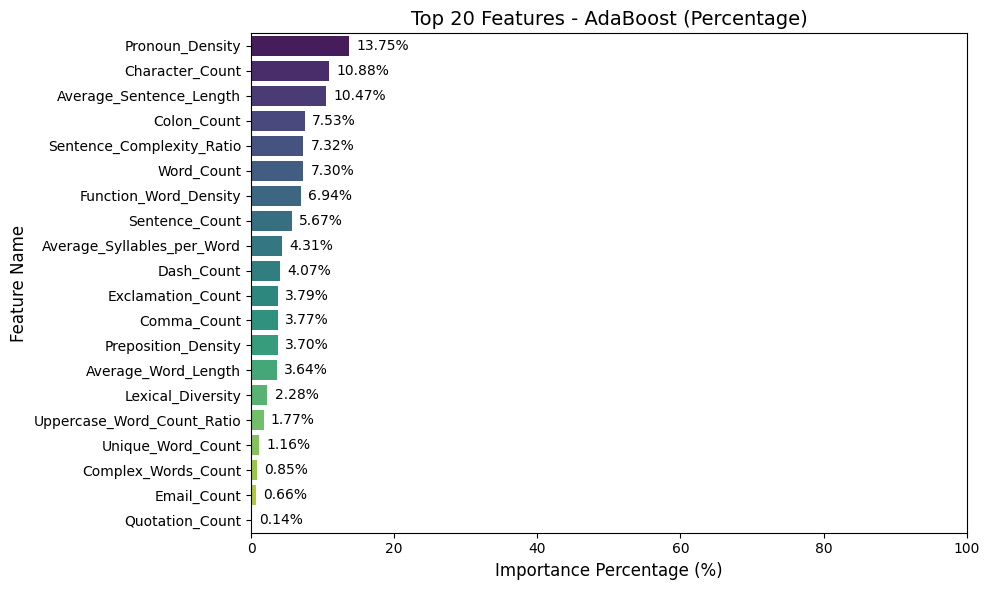


--- 📈 แสดงผลกราฟ Top Features สำหรับ AdaBoost (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


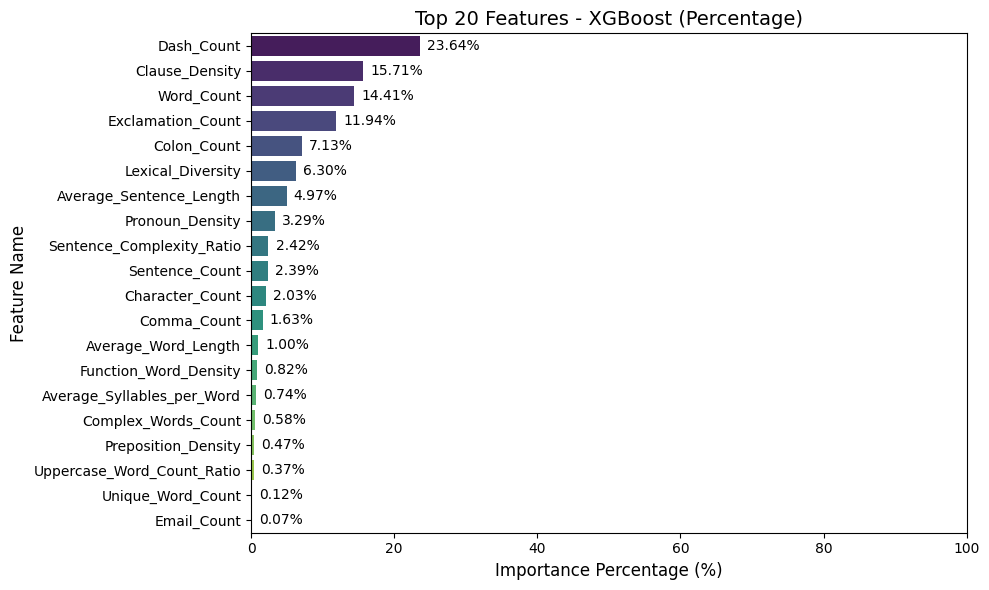


--- 📈 แสดงผลกราฟ Top Features สำหรับ XGBoost (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


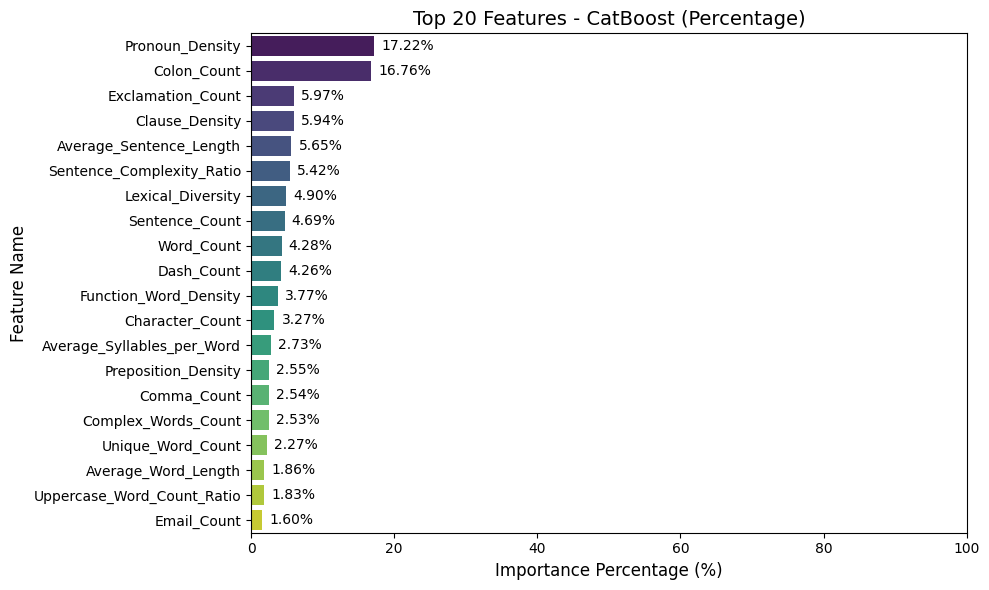


--- 📈 แสดงผลกราฟ Top Features สำหรับ CatBoost (โดยใช้ plt.show()) ---


/tmp/ipython-input-2917564384.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


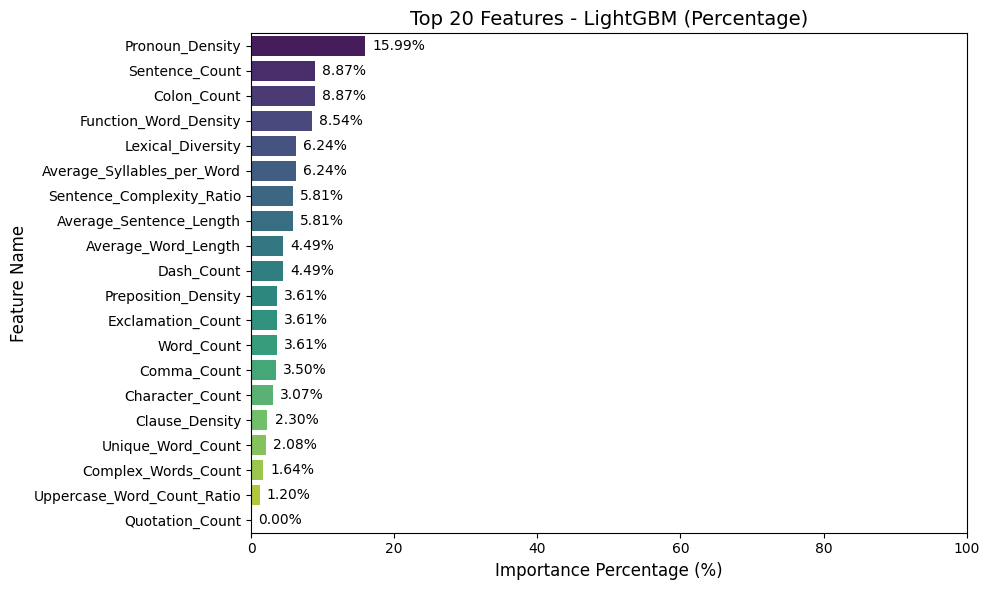


--- 📈 แสดงผลกราฟ Top Features สำหรับ LightGBM (โดยใช้ plt.show()) ---

✅ Pipeline การวิเคราะห์และการประเมินผลโมเดลเสร็จสมบูรณ์


In [47]:
# ==========================================================
# 5. # Part 4 : Main script – Run pipeline
# ==========================================================
if __name__ == "__main__":

    # 1. โหลดข้อมูล (ใช้ Dummy Data สำหรับ Execution Test)
    DATA_PATH = "email_features.csv"
    try:
        df = load_email_csv(DATA_PATH)
    except FileNotFoundError as e:
        print(f"🛑 ข้อผิดพลาดร้ายแรง: ไม่พบไฟล์ข้อมูล {DATA_PATH} ({e})")
        exit()

    # 2. สร้าง DataFrame ฟีเจอร์
    print("\n--- 1. Feature Engineering ---")
    feature_df = build_feature_dataframe(df)

    # 3. เตรียม X และ y
    X, y, feature_cols = prepare_X_y(feature_df, label_col="Label")
    print(f"✅ ข้อมูลพร้อมสำหรับการฝึกโมเดล: X shape={X.shape}, Phishing rate={y.mean():.2f}")

    # 4. แบ่งข้อมูลสำหรับ Train-Test Split (80/20)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    base_models = get_models()

    # ==========================================================
    # 📌 RUN 1: EVALUATION ด้วย TRAIN-TEST SPLIT (80/20)
    # ==========================================================
    print("\n" + "="*80)
    print("RUN 1: 📊 EVALUATION - TRAIN-TEST SPLIT (80/20) & VISUALIZATION")
    print("="*80)

    # 5. Training Models (80/20)
    trained_models_split = train_models_split(base_models, X_train, y_train)

    # 6. Evaluation (80/20 Test Set)
    df_metrics_split, cm_dfs = evaluate_all_models_split(trained_models_split, X_test, y_test)

    # 7. แสดงผล Summary Metrics และ Confusion Matrix (80/20)
    print("\n--- 📊 Summary Metrics (80/20 Test Split) ---")
    print(df_metrics_split.to_markdown(index=True))

    for model_name, cm_df in cm_dfs.items():
        print(f"\n--- 📊 {model_name} Confusion Matrix (80/20 Split) ---")
        print(cm_df.to_markdown(index=True))

    # 8. Plot PR Curve (80/20 Test Set)
    print("\n--- 📈 Precision-Recall Curve ---")
    plot_pr_curve(trained_models_split, X_test, y_test)

    # 🎯 9. Plot ROC Curve (ส่วนที่เพิ่มเข้ามาใหม่)
    print("\n--- 📈 Receiver Operating Characteristic (ROC) Curve ---")
    plot_roc_curve(trained_models_split, X_test, y_test)

    # ==========================================================
    # 📌 RUN 3: TOP FEATURE ANALYSIS
    # ==========================================================
    print("\n" + "="*80)
    print("🔥 RUN 3: TOP FEATURE ANALYSIS (จาก 80% Training Split)")
    print("="*80)
    for name, model in trained_models_split.items():
        display_top_features(name, model, X_train, top_n=20)

    print("\n✅ Pipeline การวิเคราะห์และการประเมินผลโมเดลเสร็จสมบูรณ์")